# Long Short-Term Memory Modeling

Train and evaluate a Long Short-Term Memory (LSTM) model to predict nucleotide changes in DENV genome regions (E, 5′UTR, 3′UTR) using environmental data (temperature, CO₂), as part of a comparative study for climate-aware viral evolution forecasting.

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)

import joblib

2025-07-24 23:12:49.170148: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Load processed data

In [2]:
df = pd.read_csv('../data/processed_genomic_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (359, 2017)


,Avg_Temp_C,CO2_Emission_Mt,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,...,p_2006,p_2007,p_2008,p_2009,p_2010,p_2011,p_2012,p_2013,p_2014,p_2015
0,26.16,2489.9,4,4,3,1,4,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
2,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
3,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
4,26.16,2489.9,4,3,2,3,3,1,4,4,...,0,0,0,0,0,0,0,0,0,0


### Define features and targets (X & y)

In [3]:
feature_cols = df.columns[:2]        
target_cols = df.columns[2:]         

X = df[feature_cols]
y = df[target_cols]

print("Shape of X (features):", X.shape)
print("Shape of y (targets):", y.shape)

Shape of X (features): (359, 2)
Shape of y (targets): (359, 2015)


### Train-Test Split

In [4]:
# 70% train, 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 251
Test set size: 108


### Reshape input data

In [5]:
X_train_lstm = X_train.values.reshape(-1, 1, 2)
X_test_lstm = X_test.values.reshape(-1, 1, 2)

### LSTM Model Architecture and Training

We adapt a simple LSTM architecture by reshaping the environmental feature input and employing a multi-output softmax layer, enabling simultaneous multi-class prediction across all 2015 nucleotide positions based solely on environmental variables.

#### Define the model

In [6]:
model = Sequential([
    Input(shape=(1, 2)),
    LSTM(64, return_sequences=False),  
    Dense(2015 * 5, activation='softmax'),
    Reshape((2015, 5))
])

#### Compile the model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Print the summary

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10075)          │       654,875 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 2015, 5)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 672,027 (2.56 MB)

 Trainable params: 672,027 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

#### Early stopping callback

In [9]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#### Fit the model

In [10]:
history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.2666 - loss: 1.5987 - val_accuracy: 0.3967 - val_loss: 1.5561
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3839 - loss: 1.5498 - val_accuracy: 0.4165 - val_loss: 1.5126
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4072 - loss: 1.5076 - val_accuracy: 0.4232 - val_loss: 1.4761
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3933 - loss: 1.4820 - val_accuracy: 0.4232 - val_loss: 1.4461
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4217 - loss: 1.4405 - val_accuracy: 0.4239 - val_loss: 1.4179
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4063 - loss: 1.4216 - val_accuracy: 0.4258 - val_loss: 1.3906
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4197 - loss: 1.3889 - val_accuracy: 0.4247 - val_loss: 1.3673
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4193 - loss: 1.3668 - val_accuracy: 0.4256 - val_loss: 1.3495


**Model Hyperparameter Choices:**

- *LSTM Units = 64:*

    The LSTM layer contains 64 memory units, providing the network with sufficient capacity to model potential nonlinear dependencies between environmental features and nucleotide positions. This configuration offers a balance between expressive power and computational efficiency, and is widely used as a default for sequence modeling tasks, even when sequence length is minimal.

- *Input Shape = (1, 2):*

    The environmental variables are reshaped to mimic a sequence of length one, enabling compatibility with the LSTM architecture while ensuring a fair comparison with the other models. This approach maintains the same feature set across all models for scientific rigor.

- *Output Layer = Dense(2015×5) with Softmax, Reshaped to (2015, 5):*

    The final dense layer outputs a softmax probability distribution for each of the 2015 nucleotide positions, facilitating simultaneous multi-class classification. The output is reshaped to produce 2015 independent categorical predictions, consistent with the multi-output structure employed in the Random Forest and ANN models.

- *Loss Function = sparse_categorical_crossentropy:*

    This loss function is selected for its compatibility with integer-encoded categorical targets, avoiding the computational burden of one-hot encoding, and is a standard choice for multi-class prediction tasks in Keras.

- *Optimizer = Adam:*

    The Adam optimizer is employed for its adaptive learning rate and robust performance across a wide variety of neural network training scenarios, requiring minimal manual tuning.

- *Batch Size = 32:*

    A batch size of 32 is chosen to balance computational efficiency and the stochasticity of gradient estimates, in line with established neural network training practices.

- *Epochs = 50 with Early Stopping (patience=5):*

    Training is capped at 50 epochs, but early stopping is applied if the validation loss fails to improve for 5 consecutive epochs, safeguarding against overfitting and ensuring that the most generalizable model is retained.

*As with the Random Forest and ANN models, comprehensive hyperparameter optimization is reserved for future research to maintain computational efficiency and keep the thesis focused on core objectives.*

#### Learning curve plot

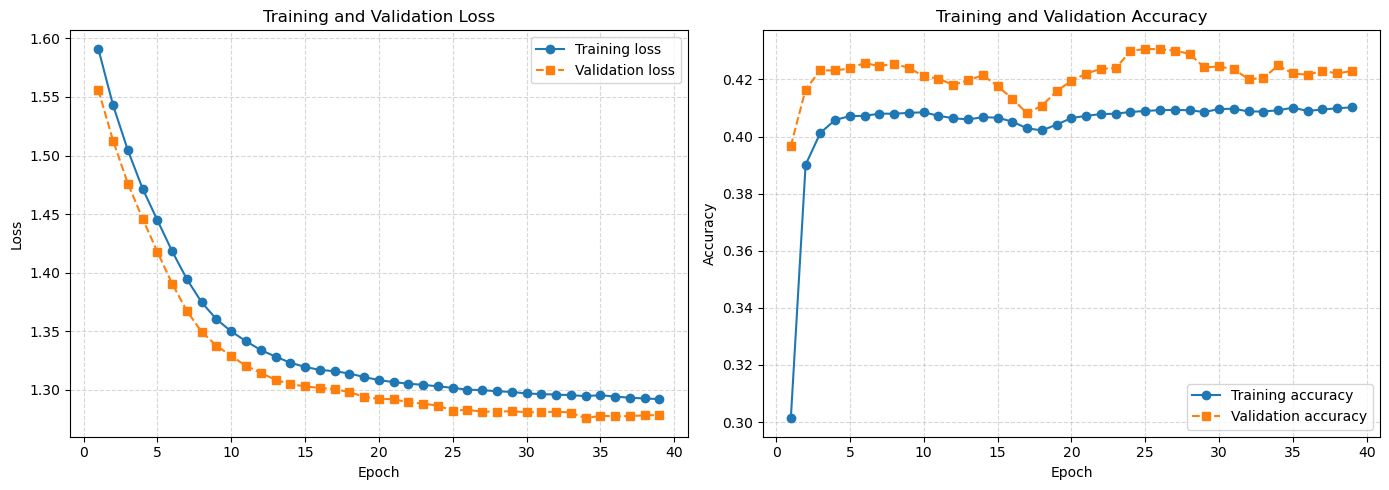

In [11]:
# Extract the history data
history_dict = history.history

# Get loss and accuracy
loss = history_dict['loss']
val_loss = history_dict['val_loss']
accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

epochs = range(1, len(loss) + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'o-', label='Training loss')
plt.plot(epochs, val_loss, 's--', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'o-', label='Training accuracy')
plt.plot(epochs, val_accuracy, 's--', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Analysis of Training and Validation Curves for LSTM Model

The above plots illustrate the training and validation loss (left) and accuracy (right) for the Long Short-Term Memory (LSTM) model across training epochs. Each point represents the model's performance on either the training set or a held-out validation set after each epoch.

#### Key Insights:

- **Model convergence and stability:**  
  Both training and validation loss exhibit a steady and consistent decline during the early epochs, followed by a gradual plateau, indicating that the model is successfully converging without evidence of instability or divergence. The close alignment between training and validation loss suggests good generalization throughout the training process.

- **Validation performance and generalization:**  
  Validation accuracy rises rapidly during the initial epochs and then stabilizes between 0.40 and 0.43 for the remainder of training. This plateau suggests the model is able to extract predictive patterns from the environmental variables and maintain stable generalization performance, without significant overfitting or degradation.

- **Accuracy trends:**  
  Both training and validation accuracy stabilize at substantially higher levels compared to the ANN model, with validation accuracy consistently exceeding 0.42 in later epochs. This indicates that the LSTM model is able to leverage the input features more effectively for multi-class nucleotide prediction, even when only environmental variables are provided as input.

- **Overfitting check:**  
  There is no significant gap between training and validation curves, suggesting the model does not overfit to the training data. The consistency of the curves supports the model's reliability in generalizing to new samples.

- **Comparative insight:**  
  Relative to the ANN model, the LSTM demonstrates improved learning dynamics and achieves validation accuracy on par with the Random Forest model. This result underscores the potential flexibility of LSTM architectures to capture weak but meaningful patterns in environmental predictors, despite the absence of explicit sequence information.

### Model Evaluation

#### Predict on test set

In [12]:
# Predict probabilities
y_pred_prob = model.predict(X_test_lstm)

# Take the argmax to get predicted class for each position
y_pred = y_pred_prob.argmax(axis=-1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


#### Overall accuracy

In [13]:
overall_accuracy = (y_pred == y_test.values).mean()
print(f"Overall nucleotide-level accuracy: {overall_accuracy:.3f}")

Overall nucleotide-level accuracy: 0.395


#### Per-position accuracy

In [14]:
per_position_accuracy = (y_pred == y_test.values).mean(axis=0)

per_position_df = pd.DataFrame({
    'position': target_cols,         
    'accuracy': per_position_accuracy
})

print(per_position_df.head())

  position  accuracy
0      p_1  0.564815
1      p_2  0.351852
2      p_3  0.388889
3      p_4  0.564815
4      p_5  0.583333


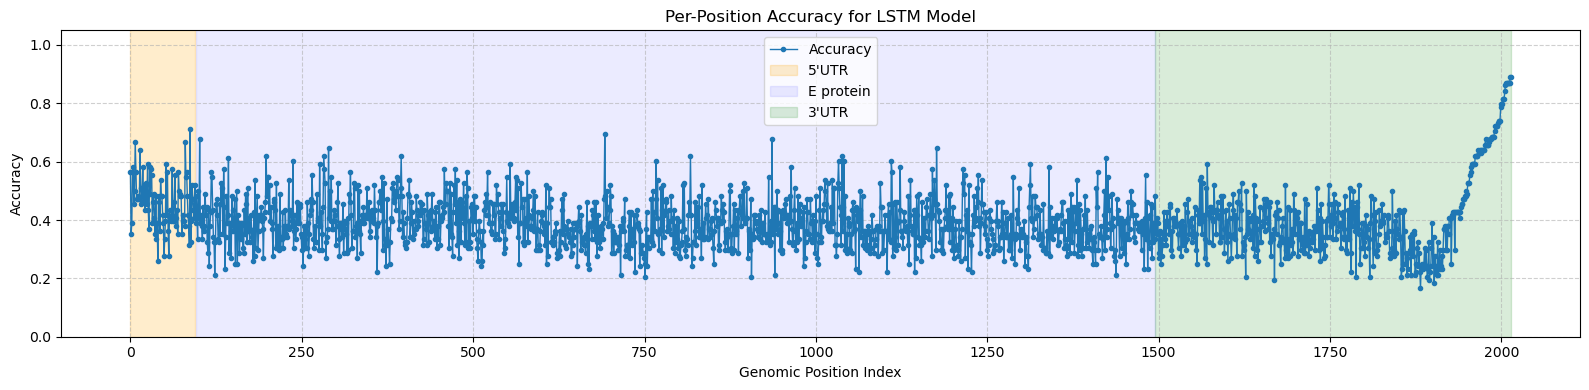

In [17]:
# Plot per-position accuracy with region labels (E, 5′UTR, 3′UTR)
utr5_start, utr5_end = 0, 94
e_start, e_end = 95, 1494
utr3_start, utr3_end = 1495, 2014

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), per_position_accuracy, marker='.', linestyle='-', linewidth=1, label='Accuracy')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per-Position Accuracy for LSTM Model') 
plt.xlabel('Genomic Position Index')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Accuracy for LSTM Model

The above plot displays the per-position nucleotide prediction accuracy of the Long Short-Term Memory (LSTM) model across the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. Each data point represents the proportion of correct nucleotide predictions at a specific genomic position in the test set, with colored background regions marking the three distinct genomic segments.

#### Key Insights:

- **Overall accuracy profile:**  
  The LSTM model achieves a notably higher and more consistent per-position accuracy across the entire genome compared to the ANN model. Accuracy values are generally centered around 0.4–0.5 for most positions, with considerable variability across sites but rarely falling to the low levels observed in the ANN results.

- **Functional region trends:**  
  Accuracy is relatively stable within the 5′UTR and E protein regions, with some fluctuations but no sustained drops. The 3′UTR region exhibits similar trends, except for the distal tail where accuracy rises steeply—consistent with sequence padding or highly conserved positions.

- **Improved predictive signal:**  
  The substantially elevated accuracy throughout the majority of positions indicates that the LSTM is able to capture more meaningful relationships between environmental variables and nucleotide identity, even without explicit sequence context.

- **Biological and technical interpretation:**  
  As with other models, the sharp increase in accuracy at the terminal end of the 3′UTR likely reflects technical artifacts from padding rather than true biological prediction. The broader pattern, however, suggests that LSTM can extract relevant features from environmental inputs for position-specific forecasting.

In [16]:
# Save per-position accuracy
per_position_df.to_csv('../results/lstm_per_position_accuracy.csv', index=False)

#### Calculate per-position Classification Report and Confusion Matrix

In [18]:
report_list = []
conf_matrix_list = []

for idx, col in enumerate(target_cols):
    y_true_col = y_test[col]
    y_pred_col = y_pred[:, idx]
    report = classification_report(y_true_col, y_pred_col, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true_col, y_pred_col)

    # Flattened classification report (main averages and support)
    row = {
        'position': col,
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'weighted_precision': report['weighted avg']['precision'],
        'weighted_recall': report['weighted avg']['recall'],
        'support': report['weighted avg']['support']
    }
    # Per-class F1, precision, recall, support
    for base in ['0', '1', '2', '3', '4']:  # Class labels as string
        if base in report:
            row[f'f1_{base}'] = report[base]['f1-score']
            row[f'precision_{base}'] = report[base]['precision']
            row[f'recall_{base}'] = report[base]['recall']
            row[f'support_{base}'] = report[base]['support']
    report_list.append(row)

    # Confusion matrix as a list
    conf_matrix_list.append({
        'position': col,
        'confusion_matrix': cm.tolist()
    })

# Convert to DataFrames
report_df = pd.DataFrame(report_list)
conf_matrix_df = pd.DataFrame(conf_matrix_list)

In [19]:
report_df.head()

,position,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,support,f1_1,precision_1,...,recall_3,support_3,f1_4,precision_4,recall_4,support_4,f1_0,precision_0,recall_0,support_0
0,p_1,0.180473,0.141204,0.25,0.407736,0.319016,0.564815,108.0,0.721893,0.564815,...,0.0,24.0,0.00,0.000000,0.0,5.0,NaN,NaN,NaN,NaN
1,p_2,0.130137,0.087963,0.25,0.183156,0.123800,0.351852,108.0,0.520548,0.351852,...,0.0,28.0,0.00,0.000000,0.0,21.0,NaN,NaN,NaN,NaN
2,p_3,0.140000,0.097222,0.25,0.217778,0.151235,0.388889,108.0,0.000000,0.000000,...,0.0,22.0,0.56,0.388889,1.0,42.0,NaN,NaN,NaN,NaN
3,p_4,0.180473,0.141204,0.25,0.407736,0.319016,0.564815,108.0,0.000000,0.000000,...,0.0,14.0,0.00,0.000000,0.0,18.0,NaN,NaN,NaN,NaN
4,p_5,0.184211,0.145833,0.25,0.429825,0.340278,0.583333,108.0,0.000000,0.000000,...,1.0,63.0,0.00,0.000000,0.0,11.0,NaN,NaN,NaN,NaN


In [20]:
conf_matrix_df.head()

,position,confusion_matrix
0,p_1,"[[61, 0, 0, 0], [18, 0, 0, 0], [24, 0, 0, 0], ..."
1,p_2,"[[38, 0, 0, 0], [21, 0, 0, 0], [28, 0, 0, 0], ..."
2,p_3,"[[0, 0, 0, 10], [0, 0, 0, 34], [0, 0, 0, 22], ..."
3,p_4,"[[0, 15, 0, 0], [0, 61, 0, 0], [0, 14, 0, 0], ..."
4,p_5,"[[0, 0, 15, 0], [0, 0, 19, 0], [0, 0, 63, 0], ..."


#### Plot Macro F1 from classification report

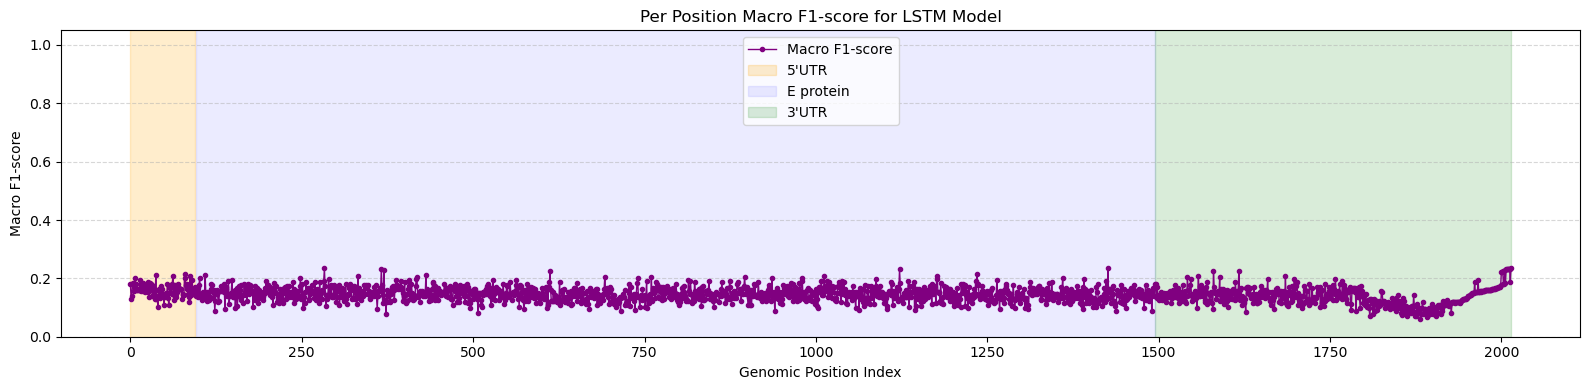

In [21]:
# Extract macro F1 for all positions
positions = report_df['position']
macro_f1 = report_df['macro_f1']

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), macro_f1, marker='.', linestyle='-', linewidth=1, color='purple', label='Macro F1-score')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per Position Macro F1-score for LSTM Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Macro F1-score')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Macro F1-score for LSTM Model

The above plot illustrates the macro-averaged F1-score at each nucleotide position for the Long Short-Term Memory (LSTM) model, evaluated across the 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome. The macro F1-score provides a balanced metric of predictive performance across all nucleotide classes (A, T, G, C, N) at each genomic position, accounting for both precision and recall irrespective of class imbalance.

#### Key Insights:

- **Uniformly moderate F1 performance:**  
  The macro F1-score remains consistently higher than that observed in the ANN model, with values generally centered around 0.15–0.20 across most positions. This indicates that the LSTM is able to achieve reasonable multi-class prediction performance throughout the genome when provided only with environmental variables.

- **Stability across genomic regions:**  
  The F1-scores are stable across the 5′UTR, E protein, and 3′UTR regions, showing no dramatic drops or spikes except near the terminal end of the sequence, where a mild upward trend is again observed due to technical padding or highly conserved positions.

- **Technical artifact at the sequence tail:**  
  As seen with other models, the gradual increase in F1-score at the end of the 3′UTR likely reflects sequence padding and should be interpreted as a technical artifact rather than evidence of genuine biological learning.

#### Plot Per-Class F1 from classification report

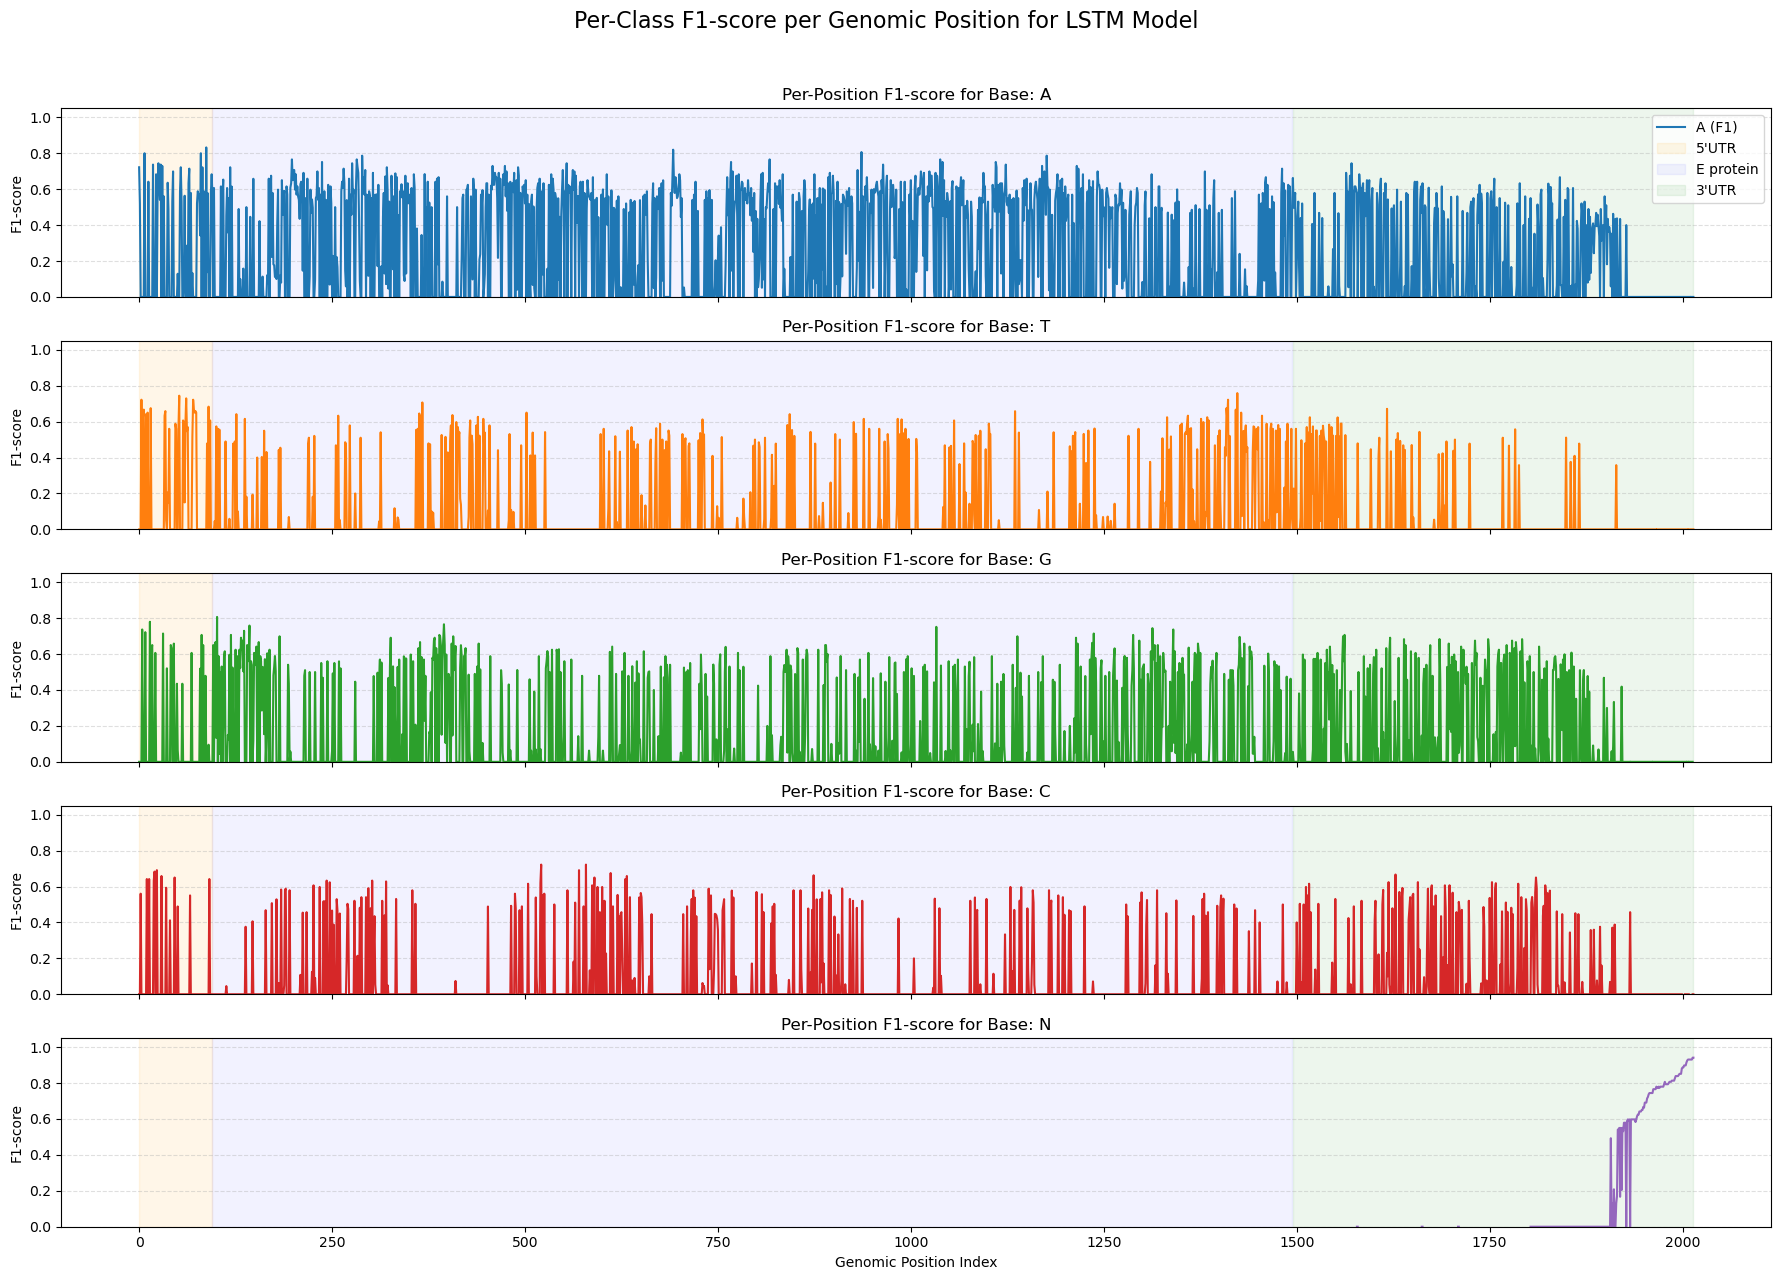

In [22]:
class_labels = {
    '1': 'A',
    '2': 'T',
    '3': 'G',
    '4': 'C',
    '0': 'N'
}
class_keys = ['1','2','3','4','0']
f1_matrix = report_df[[f'f1_{key}' for key in class_keys]].values

n_classes = len(class_keys)
fig, axes = plt.subplots(n_classes, 1, figsize=(18, 2.5 * n_classes), sharex=True, sharey=True)

for idx, key in enumerate(class_keys):
    ax = axes[idx]
    ax.plot(range(len(report_df)), f1_matrix[:, idx], label=f"{class_labels[key]} (F1)", color='C'+str(idx))
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-Position F1-score for Base: {class_labels[key]}")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    # Highlight regions (only label once in legend)
    ax.axvspan(utr5_start, utr5_end, color='orange', alpha=0.09, label="5'UTR" if idx==0 else None)
    ax.axvspan(e_start, e_end, color='blue', alpha=0.05, label="E protein" if idx==0 else None)
    ax.axvspan(utr3_start, utr3_end, color='green', alpha=0.07, label="3'UTR" if idx==0 else None)
    if idx == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel("Genomic Position Index")
plt.suptitle("Per-Class F1-score per Genomic Position for LSTM Model", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Analysis of Per-Class F1-score per Genomic Position for LSTM Model

The above figure displays the per-position F1-score for each nucleotide base (A, T, G, C, N) across the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome, as predicted by the Long Short-Term Memory (LSTM) model. Each subplot corresponds to one nucleotide class, with colored backgrounds indicating the major genomic regions.

#### Key Insights:

- **Consistent, elevated F1-scores for major bases:**  
  The F1-scores for A, T, G, and C remain consistently higher than those observed for the ANN model, often exceeding 0.4–0.5 at many positions. This indicates the LSTM model’s improved ability to correctly classify individual nucleotides at specific genomic positions using only environmental variables as input.

- **Base-specific performance variation:**  
  While all four major nucleotide classes show generally strong F1-scores across much of the genome, there is notable variability, with occasional dips and peaks that reflect differences in class distribution, site conservation, or the inherent difficulty of the classification task at certain positions.

- **'N' base artifact:**  
  The F1-score for the 'N' (padding/unknown) base is minimal throughout most of the sequence but rises sharply at the distal end of the 3′UTR. As with other models, this reflects technical padding and not genuine biological prediction.

- **Regional consistency:**  
  The strong F1 performance is observed consistently across the 5′UTR, E protein, and 3′UTR, with only minor local fluctuations. This suggests that the LSTM model is robust to regional genomic differences when forecasting nucleotide identity from environmental data.

#### Heatmap for Confusion Matrix¶

In [23]:
# Merge to associate macro_f1 with each confusion matrix
merged_df = pd.merge(report_df[['position', 'macro_f1']], conf_matrix_df, on='position')

base_labels = ['N', 'A', 'T', 'G', 'C']

def plot_conf_matrices_grid(df, positions, base_labels, fig_title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for idx, pos in enumerate(positions):
        cm = np.array(df[df['position'] == pos]['confusion_matrix'].values[0])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=base_labels, yticklabels=base_labels, 
                    ax=axes[idx], cbar=False)
        axes[idx].set_title(f"{pos}")
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')
    # Hide any unused subplots (if less than 10)
    for i in range(len(positions), 10):
        axes[i].axis('off')
    plt.suptitle(fig_title, fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

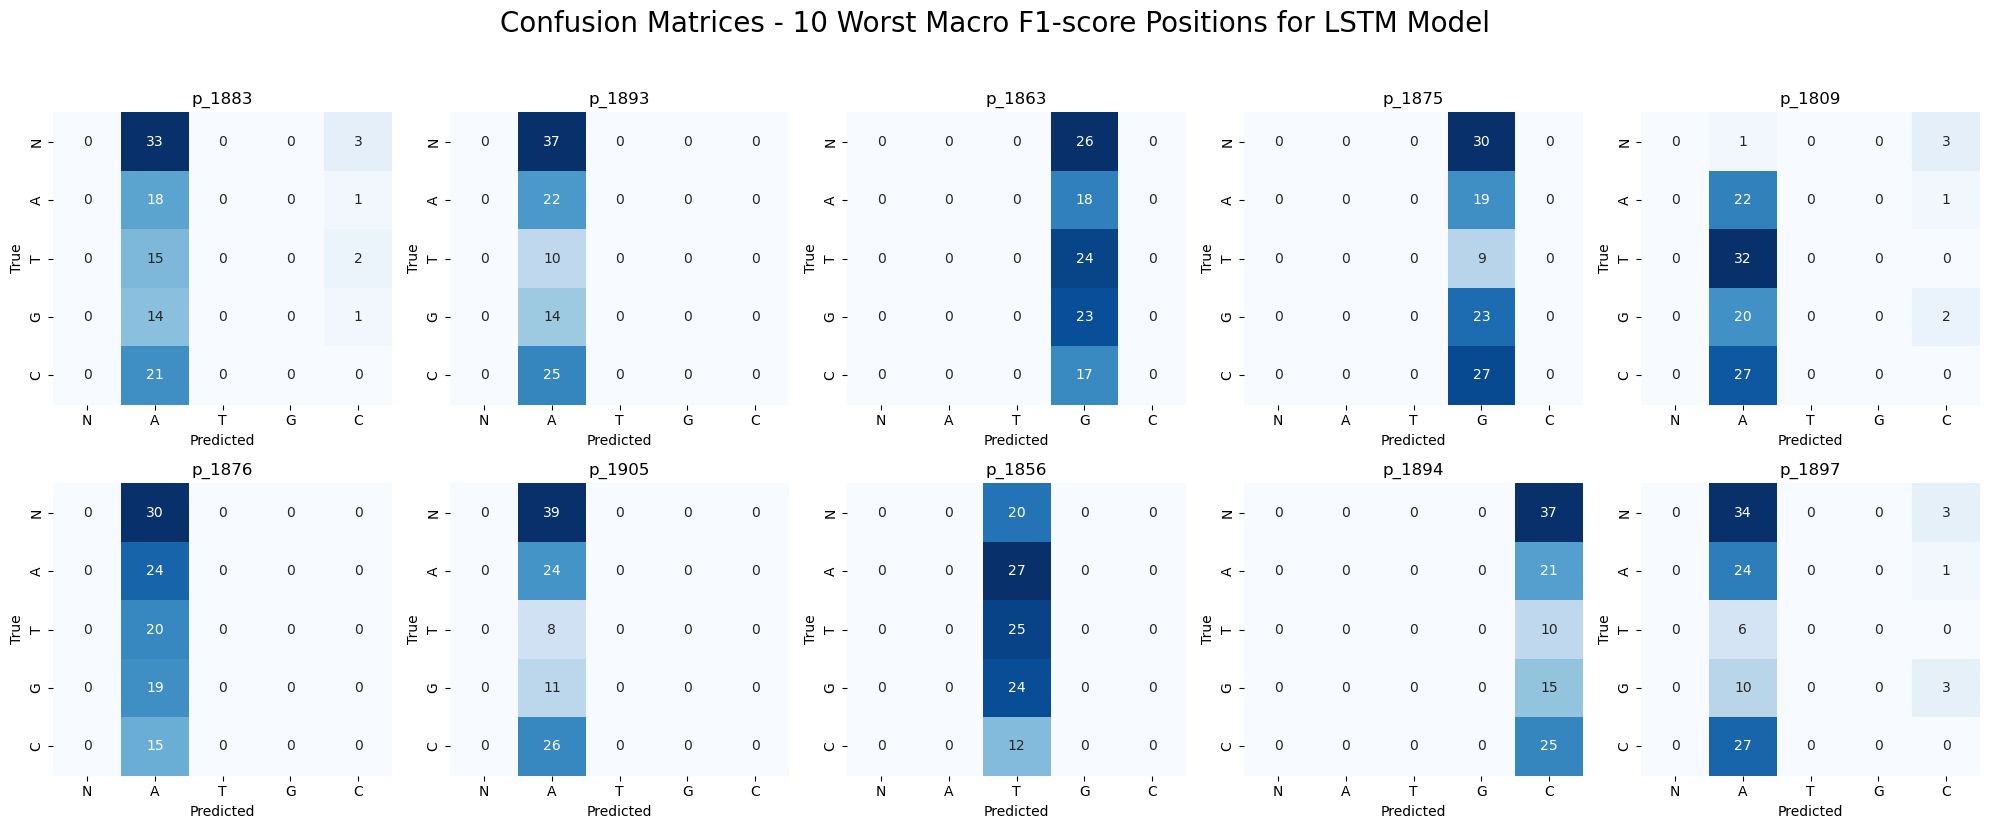

In [24]:
# 10 worst F1-score positions
worst_10 = merged_df.nsmallest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, worst_10, base_labels, "Confusion Matrices - 10 Worst Macro F1-score Positions for LSTM Model")

### Analysis of Confusion Matrices — 10 Worst Macro F1-score Positions for LSTM Model

The above figure displays confusion matrices for the 10 nucleotide positions with the lowest macro F1-scores in the Long Short-Term Memory (LSTM) model. Each matrix summarizes the correspondence between true and predicted nucleotide classes (N, A, T, G, C) at a single genomic position, highlighting the most challenging sites for the model.

#### Key Insights:

- **Consistent misclassification patterns:**  
  At these worst-performing positions, the model exhibits a strong tendency to predict a single nucleotide class for nearly all samples—most often A or G—regardless of the true base. This is evident in the concentration of counts in a single column and the near absence of correct predictions along the diagonal.

- **Minimal true positive predictions:**  
  Correct classifications are rare, with true nucleotides almost never predicted correctly. Instead, there is a systematic collapse toward a single predicted class, reflecting the model's difficulty in capturing discriminative signals from environmental variables at these particular sites.

- **Sparse predictions for minority classes:**  
  The confusion matrices show almost no predictions for some nucleotide classes (T, C, N) at these positions, which may be due to class imbalance or low variability at these sites in the dataset.

- **Implications for model reliability:**  
  These results highlight the existence of "hard" positions where the LSTM model, even with its capacity to model complex relationships, is unable to make meaningful predictions from the available input features. This underscores the limitations of climate-only forecasting for certain nucleotide sites.

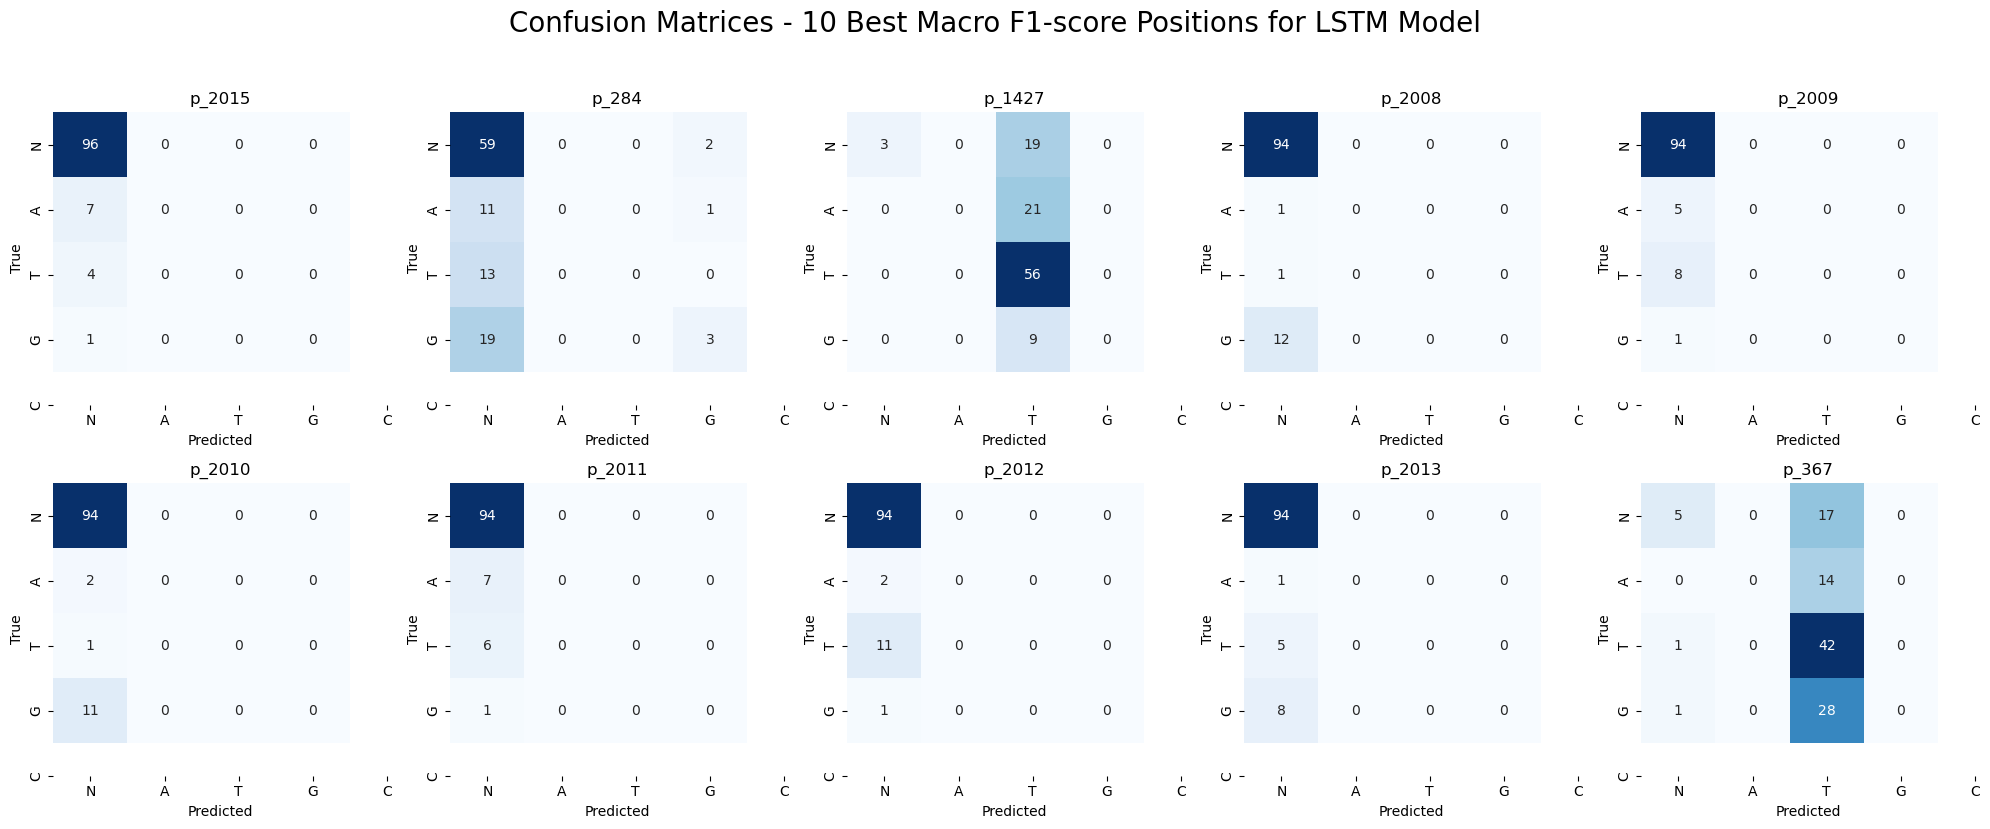

In [25]:
# 10 best F1-score positions
best_10 = merged_df.nlargest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, best_10, base_labels, "Confusion Matrices - 10 Best Macro F1-score Positions for LSTM Model")

### Analysis of Confusion Matrices — 10 Best Macro F1-score Positions for LSTM Model

The above figure displays confusion matrices for the 10 nucleotide positions with the highest macro F1-scores in the Long Short-Term Memory (LSTM) model. Each matrix summarizes the correspondence between true and predicted nucleotide classes (N, A, T, G, C) at a single genomic position, highlighting the sites where the model performed best.

#### Key Insights:

- **Accurate classification in padded and conserved regions:**  
  Many of the best-performing positions are dominated by the 'N' (padding/unknown) class, where the model nearly perfectly predicts the majority class. This results in high macro F1-scores at these positions, but primarily reflects technical artifacts rather than true biological learning.

- **Effective discrimination at certain non-padded positions:**  
  Some confusion matrices (such as those for positions p_284, p_1427, and p_367) show more distributed true and predicted values, with substantial counts along the diagonal for classes other than 'N'. This indicates that the LSTM model is able to accurately classify genuine nucleotide bases at a subset of positions, demonstrating its potential to capture real sequence-environment associations.

- **Low rates of misclassification:**  
  At these best positions, off-diagonal errors are minimal, and the majority of predictions fall into the correct class. This high level of precision and recall for specific sites highlights the capacity of the LSTM model to achieve strong performance when local sequence conservation or environmental signal is sufficient.

- **Implication for model utility:**  
  The presence of high-performing positions that are not solely dominated by the 'N' class demonstrates that, while technical padding boosts performance at sequence ends, the LSTM can still provide meaningful predictions for functionally relevant genomic sites under certain conditions.

- **Comparative context:**  
  These results reinforce findings from accuracy and F1-score analyses, confirming that the LSTM model’s strongest performance is concentrated at both highly conserved (or padded) positions and select biologically variable sites, underscoring the value of diverse evaluation metrics in model assessment.

In [26]:
# Save to CSV (or JSON for confusion matrices)
report_df.to_csv('../results/lstm_per_position_classification_report.csv', index=False)
conf_matrix_df.to_json('../results/lstm_per_position_confusion_matrices.json', orient='records')

### Save the model

In [27]:
joblib.dump(model, '../models/rnn_lstm_model.joblib')

['../models/rnn_lstm_model.joblib']